# Report inputs: every number and figure in `report/fig4c_report.pdf`

This notebook is the last analysis step. It reads `results/` (the four per-model runs of
`analysis.ipynb`), `prepared/` and `embeddings/`, and writes exactly two things:

* `report/figures/{fig_paper,fig_contrast,fig_sensitivity}.pdf` — the three figures, shown inline
  below as they are saved;
* `report/parameters.tex` — one `\newcommand` per quantity the report quotes.

`report/fig4c_report.tex` contains no literal result: every number in the PDF is one of the macros
written at the end of this notebook.

In [1]:
import json, re, sys
sys.path.insert(0, "..")
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from hm_fig4c import pipeline as P
from hm_fig4c.data import ENDPOINT_STYLES, endpoint_texts

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)

MODELS = ["st5-base", "st5-large", "st5-xl", "st5-xxl"]
PRIMARY = "st5-large"          # the model the report quotes in the text (Appendix A explains why)
PHASES = P.PHASES              # initial_candidates, initial_winner, revised_candidates, revised_winner

PREPARED = Path("../prepared")
RESULTS = Path("../results")
REPORT = Path("../report")
FIGURES = REPORT / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)

## 1. The paper's numbers

Quoted from Tessler et al. (2024); nothing here can be recomputed from the released data. Each
block carries the place it was read from.

In [2]:
PAPER = {
    # SM Fig. S60, "Position Embedding" panel -- the expanded version of main-text Fig. 4C (SM 5.2.2).
    "minority_share": 0.285,
    "opinions_sanity": 0.28,
    "initial_candidates": 0.28,
    "initial_winner": 0.29,
    "revised_candidates": 0.33,
    "revised_winner": 0.36,
    "revised_winner_se": 0.03,
    "n_rounds": 1047,
    # Main-text Fig. 4A (correlation of position score with Likert rating) and Fig. 4B (share of
    # group statements inside the range of their group's opinions).
    "fig4a_r": 0.64,
    "fig4b_within": 0.96,
    # Main-text Materials and Methods (SM front matter, printed p.39) and SM 5.1.3.
    "marginal_r2": 0.41,
    "conditional_r2": 0.45,
    # SM 4.4, "Main Task (Ablation) Cohorts 1-3": 100 + 150 + 99 groups, 485 + 726 + 481 = 1692
    # unique participants; SM 8 gives three questions per group, so 349 x 3 = 1047 rounds.
    "n_groups": 349,
    "n_participants": 1692,
    "rounds_per_group": 3,
}
assert PAPER["n_groups"] * PAPER["rounds_per_group"] == PAPER["n_rounds"]
PAPER

{'minority_share': 0.285,
 'opinions_sanity': 0.28,
 'initial_candidates': 0.28,
 'initial_winner': 0.29,
 'revised_candidates': 0.33,
 'revised_winner': 0.36,
 'revised_winner_se': 0.03,
 'n_rounds': 1047,
 'fig4a_r': 0.64,
 'fig4b_within': 0.96,
 'marginal_r2': 0.41,
 'conditional_r2': 0.45,
 'n_groups': 349,
 'n_participants': 1692,
 'rounds_per_group': 3}

`analysis.ipynb` carries the same literals into each `summary.json`. Checking them against each
other means the two copies cannot drift apart.

In [3]:
for model in MODELS:
    block = json.loads((RESULTS / model / "summary.json").read_text())["paper"]
    for key, value in block.items():
        if key in PAPER:
            assert abs(PAPER[key] - value) < 1e-9, (model, key, value, PAPER[key])
print("paper literals agree with all four summary.json files")

paper literals agree with all four summary.json files


## 2. Our results, by model

`analysis.ipynb` wrote one directory per embedding model. `summary.json` holds the headline
numbers, `fig4c_primary.json` the full primary specification including the cluster-bootstrap
standard errors and the phase-to-phase contrasts.

In [4]:
ours = {}
for model in MODELS:
    entry = json.loads((RESULTS / model / "summary.json").read_text())["ours"]
    primary = json.loads((RESULTS / model / "fig4c_primary.json").read_text())
    entry["n_boot"] = primary["n_boot"]
    entry["boot_se"] = {phase: primary["phases"][phase]["boot_se"] for phase in PHASES}
    entry["contrasts"] = primary["contrasts"]
    ours[model] = entry

n_boot = {ours[m]["n_boot"] for m in MODELS}
assert len(n_boot) == 1, f"models bootstrapped with different resample counts: {n_boot}"
N_BOOT = n_boot.pop()
print("bootstrap resamples per model:", N_BOOT)

bootstrap resamples per model: 500


In [5]:
rows = []
for phase in ["opinions_sanity"] + PHASES:
    row = {"phase": phase, "paper": PAPER[phase]}
    for model in MODELS:
        row[model] = ours[model][phase]
        row[model + " SE"] = ours[model]["boot_se"].get(phase)
    rows.append(row)
phase_table = pd.DataFrame(rows).set_index("phase")
phase_table.round(3)

,paper,st5-base,st5-base SE,st5-large,st5-large SE,st5-xl,st5-xl SE,st5-xxl,st5-xxl SE
phase,,,,,,,,,
opinions_sanity,0.28,0.263,NaN,0.263,NaN,0.263,NaN,0.263,NaN
initial_candidates,0.28,0.211,0.018,0.206,0.017,0.200,0.015,0.185,0.015
initial_winner,0.29,0.160,0.020,0.141,0.018,0.123,0.017,0.110,0.018
revised_candidates,0.33,0.209,0.017,0.186,0.017,0.178,0.015,0.155,0.016
revised_winner,0.36,0.199,0.018,0.164,0.017,0.157,0.015,0.136,0.016


The two contrasts the report quotes, on the primary model: winner-to-winner, and the whole process.

In [6]:
pd.DataFrame(ours[PRIMARY]["contrasts"]).T.round(3)

,diff,boot_se,boot_ci95,boot_p_le_0
revised_winner - initial_winner,0.023159,0.011653,"[-0.0007839816621439057, 0.04394277456568709]",0.03
revised_candidates - initial_candidates,-0.020821,0.015611,"[-0.04933519967832633, 0.008139582808348082]",0.896
revised_winner - initial_candidates,-0.042526,0.017558,"[-0.07721864950736489, -0.008193497425232522]",0.992


## 3. Sample and group sizes

Reconstructed from `prepared/opinions.parquet`, restricted to the pre-registered groups of cohorts
1--3 -- the sample the report compares against SM 4.4.

In [7]:
opinions_raw = pd.read_parquet(PREPARED / "opinions.parquet")
sample = P.select_cohort(opinions_raw, "cohorts_1_3", prereg_only=True)
sizes = sample.groupby(["metadata.version", "launch_id", "round_id"])["participant_id"].nunique()

GROUPS = {"min": int(sizes.min()), "max": int(sizes.max()), "n_rounds": int(len(sizes)),
          "n_groups": int(sample.groupby(["metadata.version", "launch_id"]).ngroups),
          "n_participants": int(sample["participant_id"].nunique())}
GROUPS

{'min': 4, 'max': 5, 'n_rounds': 1047, 'n_groups': 349, 'n_participants': 1720}

In [8]:
pd.DataFrame({"paper (SM 4.4)": [PAPER["n_groups"], PAPER["n_participants"], PAPER["n_rounds"]],
              "reconstructed": [GROUPS["n_groups"], GROUPS["n_participants"], GROUPS["n_rounds"]]},
             index=["groups", "unique participants", "rounds"])

,paper (SM 4.4),reconstructed
groups,349,349
unique participants,1692,1720
rounds,1047,1047


In [9]:
sizes.value_counts().sort_index().rename("rounds").rename_axis("opinions in the round").to_frame().T

opinions in the round,4,5
rounds,243,804


## 4. The position axis

The paper validates the position component score by regressing the Likert rating on it with a
random intercept per round, and reports a marginal $r^2$ of 0.41 (SM 5.1.3). `pipeline.marginal_r2`
fits that model; here it runs once per embedding model. The score column has to be rebuilt from the
embedding cache, so this cell loads all four caches and takes a couple of minutes.

In [10]:
AXIS, scored = {}, {}
for model in MODELS:
    op, _, _, cand = P.score_all(PREPARED, Path("../embeddings") / model)
    AXIS[model] = P.marginal_r2(op)
    scored[model] = (op, cand)
    print(f"{model}: marginal r2 = {AXIS[model]['marginal_r2']:.3f}, pearson r = {AXIS[model]['pearson_r']:.3f}")

axis_table = pd.DataFrame(AXIS).T[["marginal_r2", "conditional_r2", "pearson_r", "pearson_r2", "beta", "beta_se", "n", "n_rounds"]]
axis_table.round(3)

st5-base: marginal r2 = 0.291, pearson r = 0.561


st5-large: marginal r2 = 0.392, pearson r = 0.633


st5-xl: marginal r2 = 0.447, pearson r = 0.669


st5-xxl: marginal r2 = 0.503, pearson r = 0.713


,marginal_r2,conditional_r2,pearson_r,pearson_r2,beta,beta_se,n,n_rounds
st5-base,0.291,0.443,0.561,0.315,11.042,0.259,4979.0,1047.0
st5-large,0.392,0.505,0.633,0.400,10.686,0.204,4979.0,1047.0
st5-xl,0.447,0.530,0.669,0.448,9.967,0.171,4979.0,1047.0
st5-xxl,0.503,0.560,0.713,0.509,10.669,0.161,4979.0,1047.0


## 5. True minority share under the other neutral rule

The pinned rule counts a neutral (Likert 4) opinion as non-minority, as SM 5.4.1 describes. The
alternative is to drop neutral opinions from their group, which changes the true share as well as
the weight; the report quotes it in a footnote.

In [11]:
op_primary, cand_primary = scored[PRIMARY]
dropped = P.run_minority_analysis(op_primary, cand_primary, phases=["initial_winner"], include_opinions=False,
                                  neutral="drop_participant", ties="exclude")["phases"]["initial_winner"]
SHARE_DROPPED = {"true_share": dropped["true_share"], "n_rounds": dropped["n_rounds"]}

pd.DataFrame({"neutral counted as non-minority (pinned)": [ours[PRIMARY]["minority_share"], ours[PRIMARY]["n_rounds"]],
              "neutral opinion dropped": [SHARE_DROPPED["true_share"], SHARE_DROPPED["n_rounds"]]},
             index=["true minority share", "rounds"]).round(3)

,neutral counted as non-minority (pinned),neutral opinion dropped
true minority share,0.262,0.289
rounds,560.000,560.000


## 6. Endpoint readings

SM 5.1.2 fixes the endpoints as "a generic + question-specific combination". The released position
statements capitalise the negation ("should NOT be"), where the SM's example reads "is not"; both
readings are consistent with the description, so the report runs the primary specification under
each. The pinned reading must reproduce `analysis.ipynb` exactly.

In [12]:
ENDPOINT_TEST = ["prefixed", "prefixed_not_lower"]   # the pinned reading first
ENDPOINTS = {}
for style in ENDPOINT_TEST:
    op, _, _, cand = P.score_all(PREPARED, Path("../embeddings") / PRIMARY, endpoint_style=style)
    run = P.run_minority_analysis(op, cand, n_boot=N_BOOT)
    mixed = P.marginal_r2(op)
    entry = {"description": ENDPOINT_STYLES[style], "n_rounds": run["phases"]["initial_winner"]["n_rounds"],
             "true_share": run["phases"]["initial_winner"]["true_share"],
             "opinions_sanity": run["phases"]["opinions"]["weight"],
             "fig4a_r": mixed["pearson_r"], "marginal_r2": mixed["marginal_r2"]}
    for phase in PHASES:
        entry[phase] = run["phases"][phase]["weight"]
        entry[phase + "_boot_se"] = run["phases"][phase]["boot_se"]
    ENDPOINTS[style] = entry
    print(f"[{style}] revised winner = {entry['revised_winner']:.3f}, r = {entry['fig4a_r']:.3f}")

for phase in PHASES:   # the pinned reading is the one analysis.ipynb ran
    assert abs(ENDPOINTS["prefixed"][phase] - ours[PRIMARY][phase]) < 1e-6, phase
print("pinned reading reproduces the primary specification")

[prefixed] revised winner = 0.164, r = 0.633


[prefixed_not_lower] revised winner = 0.167, r = 0.631
pinned reading reproduces the primary specification


In [13]:
pd.DataFrame(ENDPOINTS).drop(index="description").round(3)

,prefixed,prefixed_not_lower
n_rounds,560,560
true_share,0.262455,0.262455
opinions_sanity,0.262923,0.262923
fig4a_r,0.632634,0.63145
marginal_r2,0.392175,0.390759
initial_candidates,0.206493,0.207885
initial_candidates_boot_se,0.016556,0.016702
initial_winner,0.140808,0.143074
initial_winner_boot_se,0.018394,0.018532
revised_candidates,0.185671,0.187234


Two worked examples of the construction: the questions asked in the most pre-registered rounds
of cohorts 1--3, with the endpoint texts each reading builds from their released position statements.

In [14]:
statements = P.select_cohort(pd.read_parquet(PREPARED / "statements.parquet"), "cohorts_1_3", prereg_only=True)
questions = pd.read_parquet(PREPARED / "questions.parquet").set_index("question_id")
counts = statements.groupby("question_id").size().rename("n_rounds").reset_index()
top = counts.sort_values(["n_rounds", "question_id"], ascending=[False, True]).head(2)

EXAMPLES = []
for qid, n_rounds in zip(top["question_id"], top["n_rounds"]):
    example = {"question_id": qid, "question": questions.at[qid, "question_text"],
               "affirming": questions.at[qid, "affirming"], "negating": questions.at[qid, "negating"],
               "n_rounds": int(n_rounds), "endpoints": {}}
    for style in ENDPOINT_TEST:
        aff, neg = endpoint_texts(example["affirming"], example["negating"], style)
        example["endpoints"][style] = {"affirming": aff, "negating": neg}
    EXAMPLES.append(example)

EXAMPLE_A, EXAMPLE_B = EXAMPLES
pd.DataFrame([{"question_id": e["question_id"], "n_rounds": e["n_rounds"], "question": e["question"],
               "pinned affirming endpoint": e["endpoints"]["prefixed"]["affirming"],
               "pinned negating endpoint": e["endpoints"]["prefixed"]["negating"],
               "'NOT' lowercased, negating": e["endpoints"]["prefixed_not_lower"]["negating"]} for e in EXAMPLES]).T

,0,1
question_id,S173964506,S173969028
n_rounds,7,7
question,Should the UK raise taxes on people earning mo...,Should employers be forced to provide their em...
pinned affirming endpoint,"Yes, I agree. The UK should raise taxes on peo...","Yes, I agree. Employers should be forced to pr..."
pinned negating endpoint,"No, I disagree. The UK should NOT raise taxes ...","No, I disagree. Employers should NOT be forced..."
"'NOT' lowercased, negating","No, I disagree. The UK should not raise taxes ...","No, I disagree. Employers should not be forced..."


## 7. The sensitivity sweep

`analysis.ipynb` ran every combination of the choices the SM leaves open under each embedding
model. Model size is the fourth axis, so the pooled sweep is the four files together.

In [15]:
sweeps = {model: pd.read_csv(RESULTS / model / "sensitivity.csv").assign(model=model) for model in MODELS}
for model, frame in sweeps.items():
    assert "error" not in frame or frame["error"].isna().all(), model
runs_per_model = {len(f) for f in sweeps.values()}
assert len(runs_per_model) == 1, f"models ran different numbers of specifications: {runs_per_model}"
N_RUNS_PER_MODEL = runs_per_model.pop()
pooled = pd.concat(sweeps.values(), ignore_index=True)

expected = len(P.NEUTRAL_OPTIONS) * len(P.ORDER_OPTIONS) + len(P.ORDER_OPTIONS)  # Likert split x neutral x order, plus score split x order
assert N_RUNS_PER_MODEL == expected, (N_RUNS_PER_MODEL, expected)
print(f"{N_RUNS_PER_MODEL} specifications per model, {len(pooled)} runs in all")
pooled[["model", "variant", "n_rounds", "true_share"] + PHASES].round(3)

6 specifications per model, 24 runs in all


,model,variant,n_rounds,true_share,initial_candidates,initial_winner,revised_candidates,revised_winner
0,st5-base,split=Likert rating | neutral=non-minority | o...,560,0.262,0.211,0.160,0.209,0.199
1,st5-base,split=Likert rating | neutral=non-minority | o...,560,0.262,0.215,0.163,0.211,0.202
2,st5-base,split=Likert rating | neutral=opinion dropped ...,560,0.289,0.238,0.191,0.240,0.232
3,st5-base,split=Likert rating | neutral=opinion dropped ...,560,0.289,0.240,0.197,0.243,0.236
4,st5-base,split=sign of position score | neutral=n/a | o...,618,0.289,0.266,0.222,0.259,0.247
5,st5-base,split=sign of position score | neutral=n/a | o...,618,0.289,0.262,0.218,0.257,0.246
6,st5-large,split=Likert rating | neutral=non-minority | o...,560,0.262,0.206,0.141,0.186,0.164
7,st5-large,split=Likert rating | neutral=non-minority | o...,560,0.262,0.209,0.145,0.188,0.166
8,st5-large,split=Likert rating | neutral=opinion dropped ...,560,0.289,0.239,0.176,0.220,0.199
9,st5-large,split=Likert rating | neutral=opinion dropped ...,560,0.289,0.241,0.180,0.220,0.201


In [16]:
def sweep_stats(frame):
    out = {"n_runs": int(len(frame)),
           # "increases from initial to final": initial candidates -> revised winner
           "prop_increase_initial_to_final": float((frame["revised_winner"] > frame["initial_candidates"]).mean()),
           "prop_final_above_true_share": float((frame["revised_winner"] > frame["true_share"]).mean()),
           "max_revised_winner": float(frame["revised_winner"].max()),
           "true_share_mean": float(frame["true_share"].mean())}
    for phase in PHASES:
        out[phase] = {"mean": float(frame[phase].mean()), "min": float(frame[phase].min()), "max": float(frame[phase].max())}
    return out

SENS = {"pooled": sweep_stats(pooled), "per_model": {model: sweep_stats(frame) for model, frame in sweeps.items()}}
pd.DataFrame({model: {(phase, stat): SENS["per_model"][model][phase][stat] for phase in PHASES for stat in ("mean", "min", "max")}
              for model in MODELS}).round(3)

st5-base  st5-large  st5-xl  st5-xxl
initial_candidates mean     0.239      0.231   0.227    0.206
                   min      0.211      0.206   0.200    0.184
                   max      0.266      0.245   0.250    0.221
initial_winner     mean     0.192      0.173   0.158    0.137
                   min      0.160      0.141   0.123    0.110
                   max      0.222      0.200   0.188    0.151
revised_candidates mean     0.236      0.213   0.207    0.180
                   min      0.209      0.186   0.178    0.155
                   max      0.259      0.233   0.229    0.194
revised_winner     mean     0.227      0.194   0.186    0.159
                   min      0.199      0.164   0.157    0.136
                   max      0.247      0.217   0.206    0.175

In [17]:
pd.Series({k: v for k, v in SENS["pooled"].items() if not isinstance(v, dict)}).to_frame("pooled sweep").round(3)

,pooled sweep
n_runs,24.000
prop_increase_initial_to_final,0.000
prop_final_above_true_share,0.000
max_revised_winner,0.247
true_share_mean,0.279


## 8. The three figures

All three are grouped bars with error bars, drawn by one routine so that they share a size, a
palette, a y-axis and the way the true-share reference lines are labelled. Two entities get
categorical hues (paper = orange, ours = blue); model size is ordinal, so the four sizes are evenly
spaced steps of the blue ramp, light to dark with size.

In [18]:
C_PAPER = "#eb6834"
MODEL_COLORS = {"st5-base": "#86b6ef", "st5-large": "#3987e5", "st5-xl": "#1c5cab", "st5-xxl": "#0d366b"}
C_RULE, C_INK, C_MUTED = "#333333", "#222222", "#666666"

LABELS = {"opinions": "Opinions\n(sanity check)", "initial_candidates": "Initial\nstatements",
          "initial_winner": "Initial\nwinner", "revised_candidates": "Revised\nstatements",
          "revised_winner": "Revised\nwinner"}
PAPER_NAME = "Paper (Tessler et al.)"

FIGSIZE = (6.6, 3.0)   # every figure is included at \linewidth, so one size keeps the type the same size throughout
YLIM = (0, 0.46)       # clears the paper's revised winner plus its error bar, and leaves room for the legend
LINE_PAPER, LINE_OURS = ":", (0, (1, 2))   # the paper's true share is drawn ":" in its colour, ours is a finer dotted rule

plt.rcParams.update({
    "font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#999999", "axes.labelcolor": C_INK, "text.color": C_INK,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED, "figure.dpi": 200,
    "axes.grid": True, "grid.color": "#E6E6E6", "grid.linewidth": 0.6, "axes.axisbelow": True,
})


def grouped_bars(ax, groups, series, group_width=0.8):
    """Draw one bar per (group, series) with an optional error bar, and return the group centres.

    Each series is {"name", "vals", "err", "color"}; an err entry is None (no bar), a half-width (symmetric) or a
    (below, above) pair (asymmetric, e.g. a min-max range). Series are drawn left to right in the order given."""
    x = np.arange(len(groups))
    n = len(series)
    w = group_width / n
    for i, s in enumerate(series):
        xs = x + (i - (n - 1) / 2) * w
        ax.bar(xs, s["vals"], width=w * 0.9, color=s["color"], label=s["name"])
        for xi, v, e in zip(xs, s["vals"], s["err"]):
            if e is None:
                continue
            yerr = np.array([[e[0]], [e[1]]]) if isinstance(e, (tuple, list)) else e
            ax.errorbar(xi, v, yerr=yerr, fmt="none", ecolor=C_INK, capsize=1.5, lw=0.8)
    ax.set_xticks(x, groups)
    ax.set_xlim(-0.55, len(groups) + 0.55)   # the space past the last group holds the reference-line labels
    ax.set_ylim(*YLIM)
    ax.set_ylabel("Weight of minority opinions")
    if n > 1:
        ax.legend(frameon=False, fontsize=6.5, loc="upper left")
    return x


def reference_line(ax, x_text, y, label, color, ls, va, pad=0.004):
    """A horizontal true-share rule, labelled just past the last group; va="bottom" puts the label above the rule,
    va="top" below it, each offset by `pad` so the dotted rule never runs through the text."""
    ax.axhline(y, ls=ls, lw=1, color=color)
    ax.text(x_text, y + (pad if va == "bottom" else -pad), label, va=va, fontsize=6, color=color)


def paper_series(keys):
    """The paper's values at the given phases (SM Fig. S60), with its printed SE on the revised winner only."""
    return {"name": PAPER_NAME, "vals": [PAPER[k] for k in keys], "color": C_PAPER,
            "err": [PAPER["revised_winner_se"] if k == "revised_winner" else None for k in keys]}


def save_and_show(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.pdf", bbox_inches="tight")
    print("wrote", (FIGURES / f"{name}.pdf").as_posix())
    plt.show()

**Figure 1** — the paper's own Fig. 4C values (SM Fig. S60, position-embedding panel), redrawn.

wrote ../report/figures/fig_paper.pdf


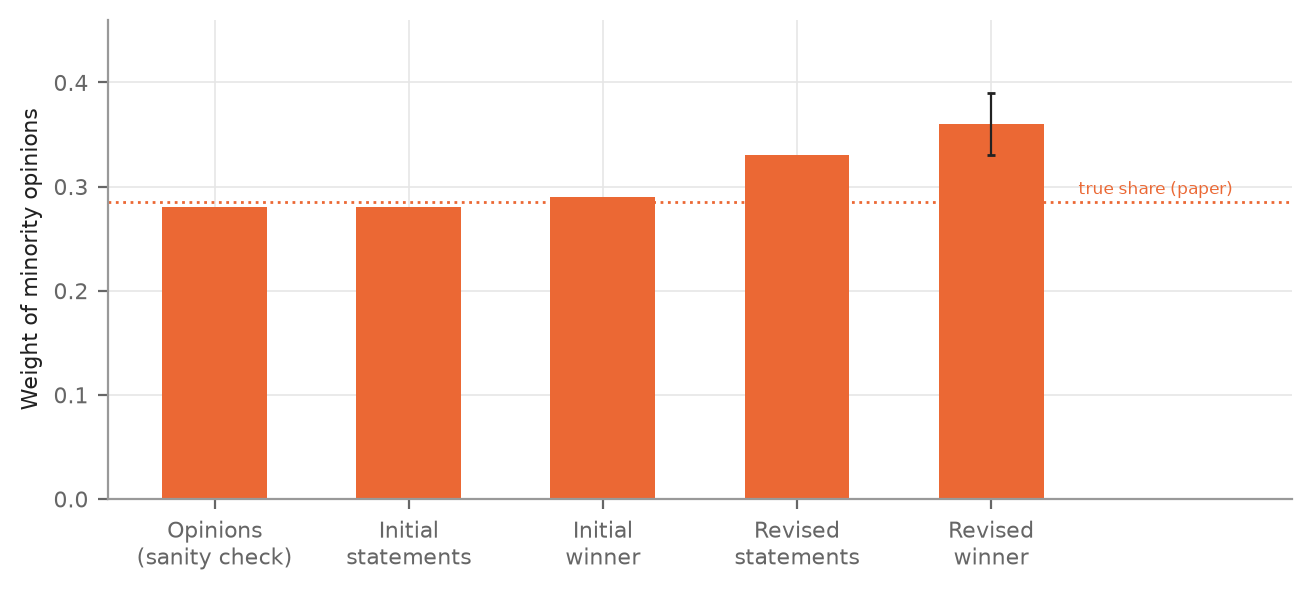

In [19]:
keys = ["opinions_sanity"] + PHASES
fig, ax = plt.subplots(figsize=FIGSIZE)
x = grouped_bars(ax, [LABELS["opinions"]] + [LABELS[k] for k in PHASES], [paper_series(keys)], group_width=0.6)
reference_line(ax, x[-1] + 0.45, PAPER["minority_share"], "true share (paper)", C_PAPER, LINE_PAPER, "bottom")
save_and_show(fig, "fig_paper")

**Figure 2** — paper vs. our reproduction under every embedding model, across the four phases.
Error bars: paper, $\pm$1 SE as printed (SM Fig. S60); ours, $\pm$1 cluster-bootstrap SE over rounds.
No per-bar value labels: the numbers are in the phases table of the report.

wrote ../report/figures/fig_contrast.pdf


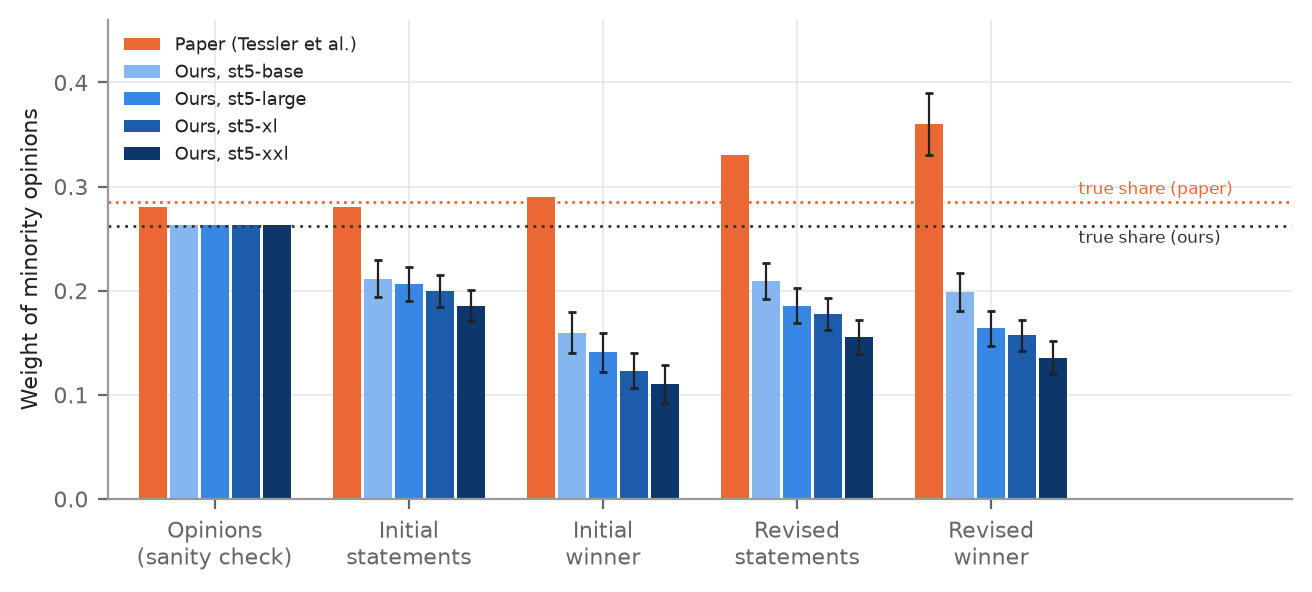

In [20]:
series = [paper_series(keys)]
for model in MODELS:
    o = ours[model]
    series.append({"name": f"Ours, {model}", "vals": [o["opinions_sanity"]] + [o[k] for k in PHASES],
                   "err": [None] + [o["boot_se"][k] for k in PHASES], "color": MODEL_COLORS[model]})
fig, ax = plt.subplots(figsize=FIGSIZE)
x = grouped_bars(ax, [LABELS["opinions"]] + [LABELS[k] for k in PHASES], series)
# The two reference lines sit ~0.02 apart: label one above its line and one below, so they never collide.
reference_line(ax, x[-1] + 0.45, PAPER["minority_share"], "true share (paper)", C_PAPER, LINE_PAPER, "bottom")
reference_line(ax, x[-1] + 0.45, ours[PRIMARY]["minority_share"], "true share (ours)", C_RULE, LINE_OURS, "top")
save_and_show(fig, "fig_contrast")

**Figure 3** — the paper against the sensitivity sweep: for each model the mean weight at each
phase over the specifications run under it, with whiskers spanning their full range (min to max).
The paper's bar carries its printed SE.

wrote ../report/figures/fig_sensitivity.pdf


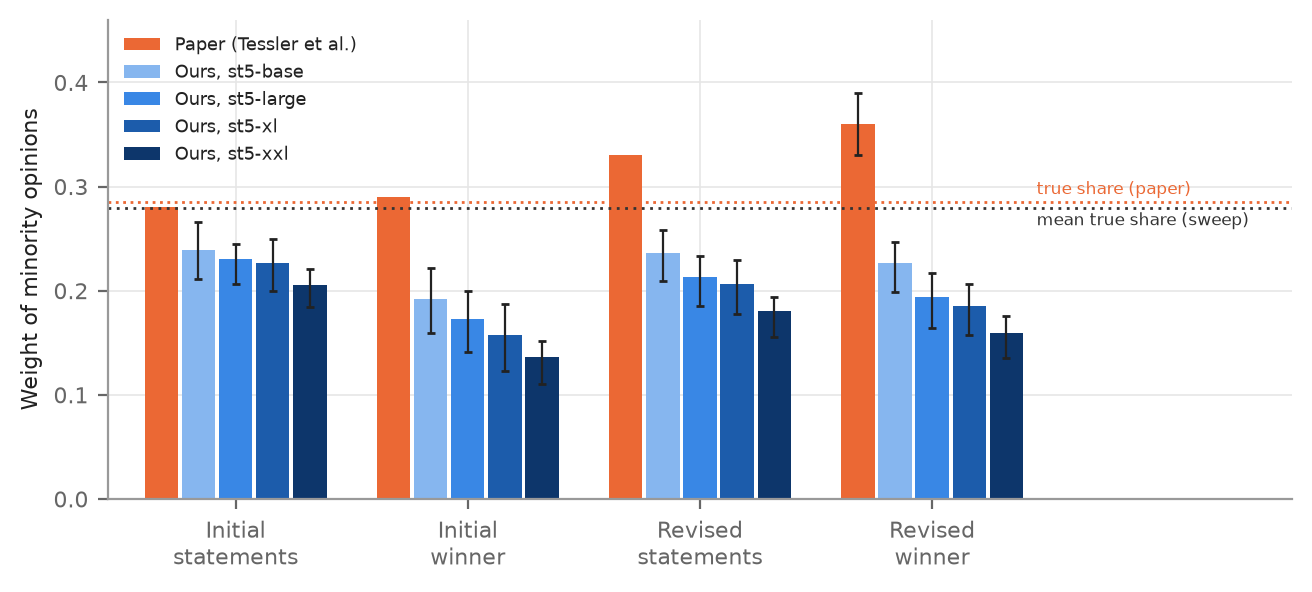

In [21]:
series = [paper_series(PHASES)]
for model in MODELS:
    s = SENS["per_model"][model]
    series.append({"name": f"Ours, {model}", "vals": [s[k]["mean"] for k in PHASES], "color": MODEL_COLORS[model],
                   "err": [(s[k]["mean"] - s[k]["min"], s[k]["max"] - s[k]["mean"]) for k in PHASES]})
fig, ax = plt.subplots(figsize=FIGSIZE)
x = grouped_bars(ax, [LABELS[k] for k in PHASES], series)
reference_line(ax, x[-1] + 0.45, PAPER["minority_share"], "true share (paper)", C_PAPER, LINE_PAPER, "bottom")
reference_line(ax, x[-1] + 0.45, SENS["pooled"]["true_share_mean"], "mean true share (sweep)", C_RULE, LINE_OURS, "top")
save_and_show(fig, "fig_sensitivity")

## 9. `report/parameters.tex`

One assignment per macro, grouped by the table or paragraph of the report that uses it. Weights,
shares and $r^2$ are printed to three decimals, the paper's own values and the Fig. 4A/4B checks to
two, counts as integers. Question texts and position statements come from the data, so they are
TeX-escaped.

In [22]:
TEX_SPECIALS = [("\\", r"\textbackslash{}"), ("&", r"\&"), ("%", r"\%"), ("$", r"\$"), ("#", r"\#"),
                ("_", r"\_"), ("{", r"\{"), ("}", r"\}"), ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}")]

def tex_escape(s):
    for ch, replacement in TEX_SPECIALS:
        s = s.replace(ch, replacement)
    return s

In [23]:
m = {}

# --- the paper's numbers: SM Fig. S60, Figs. 4A/4B, SM 5.1.3, SM 4.4 -----------------------------
m["paperShare"]            = f"{PAPER['minority_share']:.3f}"
m["paperOpinions"]         = f"{PAPER['opinions_sanity']:.2f}"
m["paperInitCand"]         = f"{PAPER['initial_candidates']:.2f}"
m["paperInitWin"]          = f"{PAPER['initial_winner']:.2f}"
m["paperRevCand"]          = f"{PAPER['revised_candidates']:.2f}"
m["paperRevWin"]           = f"{PAPER['revised_winner']:.2f}"
m["paperRevWinSE"]         = f"{PAPER['revised_winner_se']:.2f}"
m["paperNRounds"]          = f"{PAPER['n_rounds']:d}"
m["paperFigAr"]            = f"{PAPER['fig4a_r']:.2f}"
m["paperFigArSq"]          = f"{PAPER['fig4a_r'] ** 2:.2f}"
m["paperFigBwithin"]       = f"{PAPER['fig4b_within']:.2f}"
m["paperMarginalRsq"]      = f"{PAPER['marginal_r2']:.2f}"
m["paperConditionalRsq"]   = f"{PAPER['conditional_r2']:.2f}"
m["paperNGroups"]          = f"{PAPER['n_groups']:d}"
m["paperNParticipants"]    = f"{PAPER['n_participants']:d}"
m["paperRoundsPerGroup"]   = f"{PAPER['rounds_per_group']:d}"

# --- the sample we reconstruct: group-size sentence and the validation table ---------------------
m["groupMin"]              = f"{GROUPS['min']:d}"
m["groupMax"]              = f"{GROUPS['max']:d}"
m["groupNRounds"]          = f"{GROUPS['n_rounds']:d}"
m["groupNGroups"]          = f"{GROUPS['n_groups']:d}"
m["groupNParticipants"]    = f"{GROUPS['n_participants']:d}"

# --- the other neutral-opinion rule: footnote to "What is a minority group?" ---------------------
m["shareRuleNeutralDropped"] = f"{SHARE_DROPPED['true_share']:.3f}"

# --- primary specification, sentence-t5-base: phases table and Appendix A ------------------------
m["oursOpinionsBase"]      = f"{ours['st5-base']['opinions_sanity']:.3f}"
m["oursInitCandBase"]      = f"{ours['st5-base']['initial_candidates']:.3f}"
m["oursInitCandBootSEBase"] = f"{ours['st5-base']['boot_se']['initial_candidates']:.3f}"
m["oursInitWinBase"]       = f"{ours['st5-base']['initial_winner']:.3f}"
m["oursInitWinBootSEBase"] = f"{ours['st5-base']['boot_se']['initial_winner']:.3f}"
m["oursRevCandBase"]       = f"{ours['st5-base']['revised_candidates']:.3f}"
m["oursRevCandBootSEBase"] = f"{ours['st5-base']['boot_se']['revised_candidates']:.3f}"
m["oursRevWinBase"]        = f"{ours['st5-base']['revised_winner']:.3f}"
m["oursRevWinBootSEBase"]  = f"{ours['st5-base']['boot_se']['revised_winner']:.3f}"
m["oursMarginalRsqBase"]   = f"{AXIS['st5-base']['marginal_r2']:.3f}"
m["oursConditionalRsqBase"] = f"{AXIS['st5-base']['conditional_r2']:.3f}"
m["oursPearsonRBase"]      = f"{AXIS['st5-base']['pearson_r']:.3f}"
m["oursPearsonRsqBase"]    = f"{AXIS['st5-base']['pearson_r2']:.3f}"
m["oursMixedBetaBase"]     = f"{AXIS['st5-base']['beta']:.3f}"
m["oursMixedBetaSEBase"]   = f"{AXIS['st5-base']['beta_se']:.3f}"

# --- primary specification, sentence-t5-large: the model the prose quotes throughout -------------
m["oursShareLarge"]        = f"{ours['st5-large']['minority_share']:.3f}"
m["oursOpinionsLarge"]     = f"{ours['st5-large']['opinions_sanity']:.3f}"
m["oursNRoundsLarge"]      = f"{ours['st5-large']['n_rounds']:d}"
m["oursNRoundsTotalLarge"] = f"{ours['st5-large']['n_rounds_total']:d}"
m["oursFigArLarge"]        = f"{ours['st5-large']['fig4a_r']:.2f}"
m["oursFigBwithinLarge"]   = f"{ours['st5-large']['fig4b_within']:.2f}"
m["oursInitCandLarge"]     = f"{ours['st5-large']['initial_candidates']:.3f}"
m["oursInitCandBootSELarge"] = f"{ours['st5-large']['boot_se']['initial_candidates']:.3f}"
m["oursInitWinLarge"]      = f"{ours['st5-large']['initial_winner']:.3f}"
m["oursInitWinBootSELarge"] = f"{ours['st5-large']['boot_se']['initial_winner']:.3f}"
m["oursRevCandLarge"]      = f"{ours['st5-large']['revised_candidates']:.3f}"
m["oursRevCandBootSELarge"] = f"{ours['st5-large']['boot_se']['revised_candidates']:.3f}"
m["oursRevWinLarge"]       = f"{ours['st5-large']['revised_winner']:.3f}"
m["oursRevWinBootSELarge"] = f"{ours['st5-large']['boot_se']['revised_winner']:.3f}"
m["oursMarginalRsqLarge"]  = f"{AXIS['st5-large']['marginal_r2']:.3f}"
m["oursMarginalRsqGapLarge"] = f"{abs(PAPER['marginal_r2'] - AXIS['st5-large']['marginal_r2']):.3f}"
m["oursConditionalRsqLarge"] = f"{AXIS['st5-large']['conditional_r2']:.3f}"
m["oursPearsonRLarge"]     = f"{AXIS['st5-large']['pearson_r']:.3f}"
m["oursPearsonRsqLarge"]   = f"{AXIS['st5-large']['pearson_r2']:.3f}"
m["oursMixedBetaLarge"]    = f"{AXIS['st5-large']['beta']:.3f}"
m["oursMixedBetaSELarge"]  = f"{AXIS['st5-large']['beta_se']:.3f}"
m["oursMixedNLarge"]       = f"{AXIS['st5-large']['n']:d}"
m["oursMixedNRoundsLarge"] = f"{AXIS['st5-large']['n_rounds']:d}"

# --- primary specification, sentence-t5-xl: phases table and Appendix A --------------------------
m["oursOpinionsXl"]        = f"{ours['st5-xl']['opinions_sanity']:.3f}"
m["oursInitCandXl"]        = f"{ours['st5-xl']['initial_candidates']:.3f}"
m["oursInitCandBootSEXl"]  = f"{ours['st5-xl']['boot_se']['initial_candidates']:.3f}"
m["oursInitWinXl"]         = f"{ours['st5-xl']['initial_winner']:.3f}"
m["oursInitWinBootSEXl"]   = f"{ours['st5-xl']['boot_se']['initial_winner']:.3f}"
m["oursRevCandXl"]         = f"{ours['st5-xl']['revised_candidates']:.3f}"
m["oursRevCandBootSEXl"]   = f"{ours['st5-xl']['boot_se']['revised_candidates']:.3f}"
m["oursRevWinXl"]          = f"{ours['st5-xl']['revised_winner']:.3f}"
m["oursRevWinBootSEXl"]    = f"{ours['st5-xl']['boot_se']['revised_winner']:.3f}"
m["oursMarginalRsqXl"]     = f"{AXIS['st5-xl']['marginal_r2']:.3f}"
m["oursConditionalRsqXl"]  = f"{AXIS['st5-xl']['conditional_r2']:.3f}"
m["oursPearsonRXl"]        = f"{AXIS['st5-xl']['pearson_r']:.3f}"
m["oursPearsonRsqXl"]      = f"{AXIS['st5-xl']['pearson_r2']:.3f}"
m["oursMixedBetaXl"]       = f"{AXIS['st5-xl']['beta']:.3f}"
m["oursMixedBetaSEXl"]     = f"{AXIS['st5-xl']['beta_se']:.3f}"

# --- primary specification, sentence-t5-xxl: phases table and Appendix A -------------------------
m["oursOpinionsXxl"]       = f"{ours['st5-xxl']['opinions_sanity']:.3f}"
m["oursInitCandXxl"]       = f"{ours['st5-xxl']['initial_candidates']:.3f}"
m["oursInitCandBootSEXxl"] = f"{ours['st5-xxl']['boot_se']['initial_candidates']:.3f}"
m["oursInitWinXxl"]        = f"{ours['st5-xxl']['initial_winner']:.3f}"
m["oursInitWinBootSEXxl"]  = f"{ours['st5-xxl']['boot_se']['initial_winner']:.3f}"
m["oursRevCandXxl"]        = f"{ours['st5-xxl']['revised_candidates']:.3f}"
m["oursRevCandBootSEXxl"]  = f"{ours['st5-xxl']['boot_se']['revised_candidates']:.3f}"
m["oursRevWinXxl"]         = f"{ours['st5-xxl']['revised_winner']:.3f}"
m["oursRevWinBootSEXxl"]   = f"{ours['st5-xxl']['boot_se']['revised_winner']:.3f}"
m["oursMarginalRsqXxl"]    = f"{AXIS['st5-xxl']['marginal_r2']:.3f}"
m["oursConditionalRsqXxl"] = f"{AXIS['st5-xxl']['conditional_r2']:.3f}"
m["oursPearsonRXxl"]       = f"{AXIS['st5-xxl']['pearson_r']:.3f}"
m["oursPearsonRsqXxl"]     = f"{AXIS['st5-xxl']['pearson_r2']:.3f}"
m["oursMixedBetaXxl"]      = f"{AXIS['st5-xxl']['beta']:.3f}"
m["oursMixedBetaSEXxl"]    = f"{AXIS['st5-xxl']['beta_se']:.3f}"

# --- the two contrasts quoted in Results, on sentence-t5-large ----------------------------------
m["diffWinToWinLarge"]     = f"{ours['st5-large']['contrasts']['revised_winner - initial_winner']['diff']:.3f}"
m["diffWinToWinCIloLarge"] = f"{ours['st5-large']['contrasts']['revised_winner - initial_winner']['boot_ci95'][0]:.3f}"
m["diffWinToWinCIhiLarge"] = f"{ours['st5-large']['contrasts']['revised_winner - initial_winner']['boot_ci95'][1]:.3f}"
m["diffWinToWinPLarge"]    = f"{ours['st5-large']['contrasts']['revised_winner - initial_winner']['boot_p_le_0']:.3f}"
m["diffInitToFinalLarge"]  = f"{ours['st5-large']['contrasts']['revised_winner - initial_candidates']['diff']:.3f}"
m["diffInitToFinalCIloLarge"] = f"{ours['st5-large']['contrasts']['revised_winner - initial_candidates']['boot_ci95'][0]:.3f}"
m["diffInitToFinalCIhiLarge"] = f"{ours['st5-large']['contrasts']['revised_winner - initial_candidates']['boot_ci95'][1]:.3f}"

# --- endpoint readings table: statements as released (pinned) -----------------------------------
m["axisPinnedNRounds"]     = f"{ENDPOINTS['prefixed']['n_rounds']:d}"
m["axisPinnedFigAr"]       = f"{ENDPOINTS['prefixed']['fig4a_r']:.2f}"
m["axisPinnedMarginalRsq"] = f"{ENDPOINTS['prefixed']['marginal_r2']:.3f}"
m["axisPinnedInitCand"]    = f"{ENDPOINTS['prefixed']['initial_candidates']:.3f}"
m["axisPinnedInitCandBootSE"] = f"{ENDPOINTS['prefixed']['initial_candidates_boot_se']:.3f}"
m["axisPinnedInitWin"]     = f"{ENDPOINTS['prefixed']['initial_winner']:.3f}"
m["axisPinnedInitWinBootSE"] = f"{ENDPOINTS['prefixed']['initial_winner_boot_se']:.3f}"
m["axisPinnedRevCand"]     = f"{ENDPOINTS['prefixed']['revised_candidates']:.3f}"
m["axisPinnedRevCandBootSE"] = f"{ENDPOINTS['prefixed']['revised_candidates_boot_se']:.3f}"
m["axisPinnedRevWin"]      = f"{ENDPOINTS['prefixed']['revised_winner']:.3f}"
m["axisPinnedRevWinBootSE"] = f"{ENDPOINTS['prefixed']['revised_winner_boot_se']:.3f}"

# --- endpoint readings table: "NOT" lowercased, as in the SM's example ---------------------------
m["axisNotLowerFigAr"]     = f"{ENDPOINTS['prefixed_not_lower']['fig4a_r']:.2f}"
m["axisNotLowerMarginalRsq"] = f"{ENDPOINTS['prefixed_not_lower']['marginal_r2']:.3f}"
m["axisNotLowerInitCand"]  = f"{ENDPOINTS['prefixed_not_lower']['initial_candidates']:.3f}"
m["axisNotLowerInitCandBootSE"] = f"{ENDPOINTS['prefixed_not_lower']['initial_candidates_boot_se']:.3f}"
m["axisNotLowerInitWin"]   = f"{ENDPOINTS['prefixed_not_lower']['initial_winner']:.3f}"
m["axisNotLowerInitWinBootSE"] = f"{ENDPOINTS['prefixed_not_lower']['initial_winner_boot_se']:.3f}"
m["axisNotLowerRevCand"]   = f"{ENDPOINTS['prefixed_not_lower']['revised_candidates']:.3f}"
m["axisNotLowerRevCandBootSE"] = f"{ENDPOINTS['prefixed_not_lower']['revised_candidates_boot_se']:.3f}"
m["axisNotLowerRevWin"]    = f"{ENDPOINTS['prefixed_not_lower']['revised_winner']:.3f}"
m["axisNotLowerRevWinBootSE"] = f"{ENDPOINTS['prefixed_not_lower']['revised_winner_boot_se']:.3f}"

# --- worked example A of the endpoint construction ----------------------------------------------
m["exampleAQuestion"]      = tex_escape(EXAMPLE_A["question"])
m["exampleAAffirming"]     = tex_escape(EXAMPLE_A["affirming"])
m["exampleANegating"]      = tex_escape(EXAMPLE_A["negating"])
m["exampleANRounds"]       = f"{EXAMPLE_A['n_rounds']:d}"
m["exampleAPinnedAff"]     = tex_escape(EXAMPLE_A["endpoints"]["prefixed"]["affirming"])
m["exampleAPinnedNeg"]     = tex_escape(EXAMPLE_A["endpoints"]["prefixed"]["negating"])
m["exampleANotLowerAff"]   = tex_escape(EXAMPLE_A["endpoints"]["prefixed_not_lower"]["affirming"])
m["exampleANotLowerNeg"]   = tex_escape(EXAMPLE_A["endpoints"]["prefixed_not_lower"]["negating"])

# --- worked example B of the endpoint construction ----------------------------------------------
m["exampleBQuestion"]      = tex_escape(EXAMPLE_B["question"])
m["exampleBAffirming"]     = tex_escape(EXAMPLE_B["affirming"])
m["exampleBNegating"]      = tex_escape(EXAMPLE_B["negating"])
m["exampleBNRounds"]       = f"{EXAMPLE_B['n_rounds']:d}"
m["exampleBPinnedAff"]     = tex_escape(EXAMPLE_B["endpoints"]["prefixed"]["affirming"])
m["exampleBPinnedNeg"]     = tex_escape(EXAMPLE_B["endpoints"]["prefixed"]["negating"])
m["exampleBNotLowerAff"]   = tex_escape(EXAMPLE_B["endpoints"]["prefixed_not_lower"]["affirming"])
m["exampleBNotLowerNeg"]   = tex_escape(EXAMPLE_B["endpoints"]["prefixed_not_lower"]["negating"])

# --- the sweep: its size, and the summary sentences under "The sweep" ---------------------------
m["nBoot"]                 = f"{N_BOOT:d}"
m["sensNModels"]           = f"{len(MODELS):d}"
m["sensNNeutral"]          = f"{len(P.NEUTRAL_OPTIONS):d}"
m["sensNOrders"]           = f"{len(P.ORDER_OPTIONS):d}"
m["sensNRuns"]             = f"{SENS['pooled']['n_runs']:d}"
m["sensNRunsPerModel"]     = f"{N_RUNS_PER_MODEL:d}"
m["sensPropInitToFinal"]   = f"{100 * SENS['pooled']['prop_increase_initial_to_final']:.0f}\\%"
m["sensPropAboveShare"]    = f"{100 * SENS['pooled']['prop_final_above_true_share']:.0f}\\%"
m["sensMaxRevWin"]         = f"{SENS['pooled']['max_revised_winner']:.3f}"
m["sensTrueShareMean"]     = f"{SENS['pooled']['true_share_mean']:.3f}"

print(len(m), "macros")

144 macros


The report needs exactly these macros. Parameter macros are the only camelCase control
sequences in the `.tex` (LaTeX's own are all lower case, or start with a capital), so the set it
needs can be read straight off the source.

In [24]:
TEX = REPORT / "fig4c_report.tex"
source = re.sub(r"(?m)^%.*$", "", TEX.read_text())      # drop comment lines, keep escaped percents
needed = {name for name in re.findall(r"\\([A-Za-z]+)", source) if name[0].islower() and not name.islower()}

assert not needed - set(m), f"used by the report but not defined here: {sorted(needed - set(m))}"
assert not set(m) - needed, f"defined here but unused by the report: {sorted(set(m) - needed)}"
print(f"{len(needed)} macros used by fig4c_report.tex, all defined, none spare")

144 macros used by fig4c_report.tex, all defined, none spare


Written sorted by name. The comparison is against the `parameters.tex` that was on disk before
this cell ran -- in a fresh checkout, the committed one -- so a changed number shows up here.

In [25]:
OUT = REPORT / "parameters.tex"
previous = dict(re.findall(r"\\newcommand\{\\([A-Za-z]+)\}\{(.*)\}", OUT.read_text())) if OUT.exists() else {}

header = ["% GENERATED by notebooks/report.ipynb -- do not edit.",
          "% Every number in the report comes from here.", ""]
OUT.write_text("\n".join(header + [f"\\newcommand{{\\{name}}}{{{m[name]}}}" for name in sorted(m)]) + "\n")
print(f"wrote {OUT.as_posix()} ({len(m)} macros)")

shared = sorted(set(previous) & set(m))
changed = [(name, previous[name], m[name]) for name in shared if previous[name] != m[name]]
print(f"{len(shared)} macros in common with the previous parameters.tex, {len(changed)} changed, "
      f"{len(set(m) - set(previous))} new, {len(set(previous) - set(m))} dropped")
for name, was, now in changed:
    print(f"  {name}: {was} -> {now}")

wrote ../report/parameters.tex (144 macros)
144 macros in common with the previous parameters.tex, 0 changed, 0 new, 106 dropped
